In [2]:
# ── Imports ───────────────────────────────────────────────────
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.preprocessing_ni import load_data

# ── Load data ─────────────────────────────────────────────────
params, series = load_data()

print(params)
print(series.head())

Parameters : MAR(1,1) | φ=0.617062379728722, ψ=0.777070127450962, df=1.4947, σ=402.94
Series     : 475 obs [1980-02 → 2019-08]
MARParams(phi=0.617062379728722, psi=0.777070127450962, df=1.49474196142594, scale=402.939552934085, r=1, s=1, phi_se=0.0169074701095693, psi_se=0.0133880219062986)
                 cycle         u_t   residuals
Date                                          
1980-02-01  691.177365  264.677815  549.407479
1980-03-01  493.125609  188.836347  336.543540
1980-04-01   39.664662   15.189091  -68.010076
1980-05-01 -145.816544  -55.838640 -327.664611
1980-06-01  195.270617   74.776465    0.612744


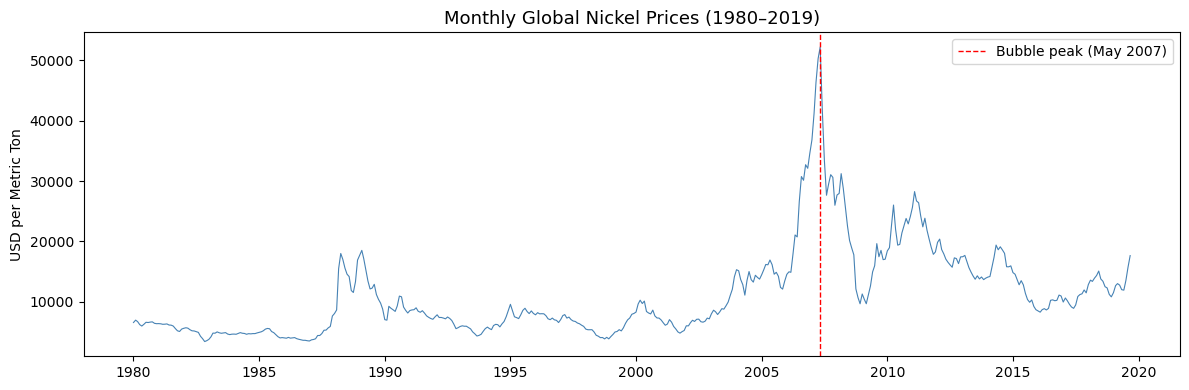

In [3]:
# ── Plot 1: Raw Nickel prices ─────────────────────────────────
raw = pd.read_csv('../../data/raw/nickel_prices_1980_2019.csv')
raw['Date'] = pd.to_datetime(raw['Date'].str.replace('M', '-'), format='%Y-%m')
raw = raw.set_index('Date')

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raw.index, raw['Nickel_Price_USD_per_MT'], 
        color='steelblue', linewidth=0.8)
ax.set_title('Monthly Global Nickel Prices (1980–2019)', fontsize=13)
ax.set_ylabel('USD per Metric Ton')
ax.set_xlabel('')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.axvline(pd.Timestamp('2007-05-01'), color='red', 
           linestyle='--', linewidth=1, label='Bubble peak (May 2007)')
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/figures/extra/01_raw_nickel_prices.png', dpi=150)
plt.show()

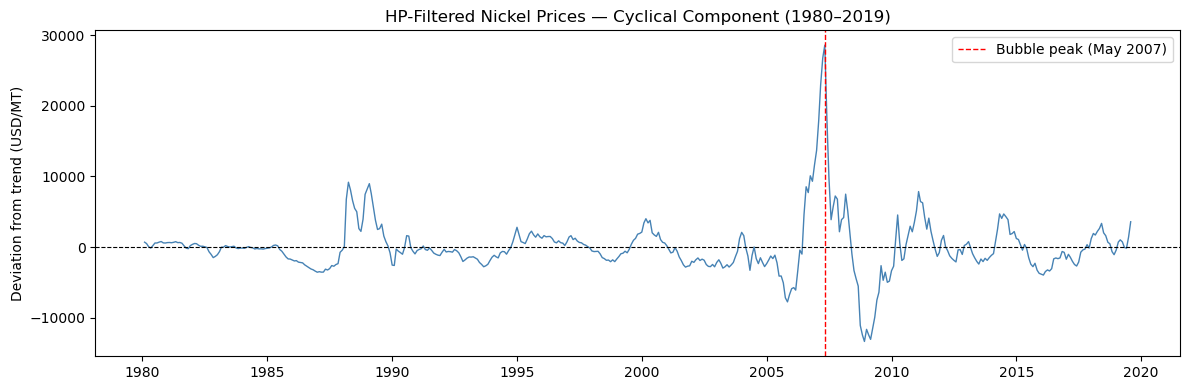

In [ ]:
# ── Plot 2: HP-filtered cycle ──────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series.index, series['cycle'], color='steelblue', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(pd.Timestamp('2007-05-01'), color='red', linewidth=1, 
           linestyle='--', label='Bubble peak (May 2007)')
ax.set_ylabel('Deviation from trend (USD/MT)')
ax.set_title('HP-Filtered Nickel Prices — Cyclical Component (1980–2019)')
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/figures/paper/02_hp_filtered_cycle.png', dpi=150)
plt.show()

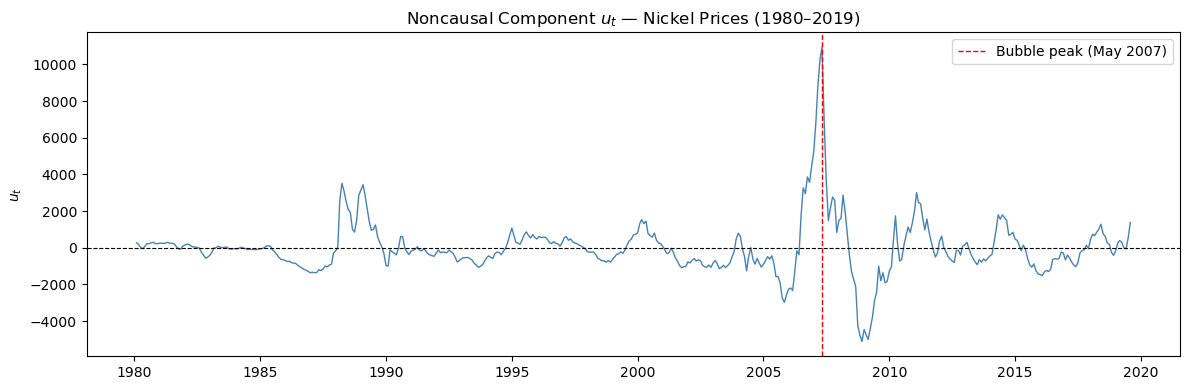

In [ ]:
# ── Plot 3: Noncausal component u_t ───────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(series.index, series['u_t'], color='steelblue', linewidth=1)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axvline(pd.Timestamp('2007-05-01'), color='red', linewidth=1,
           linestyle='--', label='Bubble peak (May 2007)')
ax.set_ylabel('$u_t$')
ax.set_title('Noncausal Component $u_t$ — Nickel Prices (1980–2019)')
ax.legend()
plt.tight_layout()
plt.savefig('../../outputs/figures/paper/03_noncausal_component.png', dpi=150)
plt.show()

Note: plots are identical, only y axis is different. Describe exactly the reason of showing u_t and why it is identical